# SNOW hand-on exercises

15th Advanced Training Course on Land Remote Sensing: The Water Cycle (https://eo4society.esa.int/event/15th-advanced-training-course-on-land-remote-sensing-the-water-cycle/)

Teachers: Carlo Marin and Valentina Premier, Eurac Research

In this notebook, we will learn how to query and access **Sentinel-2 L1C** Data through the **CDSE STAC API** for snow retrieval apllications.

we use the **[`stackstac`](https://stackstac.readthedocs.io/)** library to search and access **Sentinel-2 Level-1C (L1C)** imagery through the **[Copernicus Data Space Ecosystem (CDSE)](https://dataspace.copernicus.eu/)** **[STAC API](https://documentation.dataspace.copernicus.eu/APIs/STAC.html)**.

The **[SpatioTemporal Asset Catalog (STAC)](https://stacspec.org/en)** is an open specification for describing and discovering geospatial data. A STAC catalog organizes satellite products into **Collections** (e.g., Sentinel-2 L1C), while each acquisition is represented as a **STAC Item** containing spatial and temporal metadata together with links to the corresponding data assets (e.g., spectral bands).

The **CDSE STAC API** enables efficient searches based on an **area of interest (AOI)**, **acquisition date**, **cloud cover**, and other metadata. A major advantage of this approach is that data can be queried directly over the **AOI**, regardless of the underlying **Sentinel-2 tile grid**. This avoids manually identifying, downloading, and managing multiple **SAFE** products when the study area spans several tiles.

The **`stackstac`** library reads the returned STAC Items and constructs a lazy-loaded **`xarray.DataArray`** backed by **Dask**. Rather than downloading complete products, only the requested data are accessed on demand, making it possible to efficiently work with large datasets while presenting them as a single multidimensional data cube with dimensions such as **time**, **band**, **x**, and **y**.

In this notebook, we will:

1. Define an **AOI** and a **time range**.
2. Search the **CDSE STAC API** for **Sentinel-2 L1C** acquisitions.
3. Select the desired **spectral bands** and metadata.
4. Load the imagery into an **xarray** data cube using **`stackstac`**.
5. Read and analyze data covering **multiple Sentinel-2 tiles** as a single continuous dataset.


#### Install and import

The CDSE Geo Science kernel may already include these packages. Uncomment the installation command only if an import fails, then restart the kernel.

In [37]:
# %pip install pystac-client stackstac odc-stac geopandas shapely rasterio dask matplotlib boto3 pyproj

In [38]:
import aoi_map

import os
from getpass import getpass

import boto3
import json
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pystac_client import Client
import stackstac
from odc.stac import load as odc_load
from pyproj import CRS
from shapely.geometry import box
from pystac_client.stac_api_io import StacApiIO
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

#### 🗺️ Define an Area of Interest (AOI)

Draw a **polygon** around your study area using the interactive map below. The AOI will be saved as a **GeoJSON** file using the helper functions in `aoi_map.py` and will be used throughout this notebook to query and load **Sentinel-2** imagery from the **CDSE STAC API**.


In [39]:
m, aoi = aoi_map.create_aoi_map()
m

Map(center=[46.5, 11.3], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out…

The AOI will be saved as a GeoJSON file.

In [40]:
aoi_map.save_aoi_geojson(aoi, output_path="aoi.geojson")

PosixPath('aoi.geojson')

#### Configure CDSE S3 access

Create S3 credentials in the CDSE user area ([`S3 Credentials` → `Add Credential`](https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/auth?client_id=cdse-public&redirect_uri=https%3A%2F%2Feodata-s3keysmanager.dataspace.copernicus.eu%2F&state=aca7dc49-ebcb-4841-8201-60d922b3a004&response_mode=fragment&response_type=code&scope=openid&nonce=402de9bd-db77-4cfb-96d1-97744dfa08c1&code_challenge=H9DNWDy4lkwGf746C_0k-7LUfTH0YMHH1b_5qXIwnbM&code_challenge_method=S256). The secret key is shown only once. The following cell follows the official CDSE STAC convention: it uses `CDSE_S3_ACCESS_KEY` and `CDSE_S3_SECRET_KEY`, then maps them to the AWS variables used by GDAL.

In [41]:
if not os.environ.get("CDSE_S3_ACCESS_KEY"):
    os.environ["CDSE_S3_ACCESS_KEY"] = getpass("CDSE S3 access key: " )
if not os.environ.get("CDSE_S3_SECRET_KEY"):
    os.environ["CDSE_S3_SECRET_KEY"] = getpass("CDSE S3 secret key: " )

os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_ACCESS_KEY_ID"] = os.environ["CDSE_S3_ACCESS_KEY"]
os.environ["AWS_SECRET_ACCESS_KEY"] = os.environ["CDSE_S3_SECRET_KEY"]
os.environ["AWS_HTTPS"] = "YES"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["GDAL_HTTP_UNSAFESSL"] = "YES"
os.environ["GDAL_HTTP_TCP_KEEPALIVE"] = "YES"
os.environ["GDAL_HTTP_MULTIRANGE"] = "YES"
os.environ["CPL_VSIL_CURL_ALLOWED_EXTENSIONS"] = ".jp2,.JP2,.xml,.XML"

# Check that boto3 can see credentials without printing their values.
print("Credentials available:", bool(boto3.Session().get_credentials()))

Credentials available: True


With the **Area of Interest (AOI)** defined, we can query the **Copernicus Data Space Ecosystem (CDSE) STAC API** for available **Sentinel-2 Level-1C** acquisitions.

The AOI is loaded from the previously saved **GeoJSON** file and used as the search geometry through the `intersects` parameter. In this example, we search for scenes acquired during **January 2024** with **less than 20% cloud cover**. The query returns a collection of **STAC Items**, each representing a Sentinel-2 acquisition together with its associated metadata and links to the image assets.

In [42]:
# Load the AOI geometry
with open("aoi.geojson", "r") as f:
    aoi = json.load(f)

# Extract the geometry if the file is a GeoJSON Feature
geometry = aoi["geometry"] if aoi["type"] == "Feature" else aoi

# Open the CDSE STAC catalog
catalog = Client.open("https://stac.dataspace.copernicus.eu/v1")

# Search for Sentinel-2 L1C scenes
search = catalog.search(
    collections=["sentinel-2-l1c"],
    intersects=geometry,
    datetime="2024-01-01/2024-01-31",
    query={"eo:cloud_cover": {"lt": 20}},
)

items = list(search.items())

print(f"Found {len(items)} scenes")

Found 9 scenes


#### 📋 Inspect the Search Results

The search returns a list of **STAC Items**, where each item corresponds to a single **Sentinel-2 acquisition**. We first inspect the basic metadata of each scene, including its **identifier**, **acquisition date**, and **estimated cloud cover**.

Next, we examine the first STAC Item to see which **assets** are available. Assets are the individual files associated with a scene, such as the spectral bands (e.g., **B02**, **B03**, **B04**, **B08**), quality masks, and metadata. These asset names will be used in the next step to select the bands that we want to load with **`stackstac`**.


In [43]:
for item in items:
    print(item.id, item.datetime, item.properties.get("eo:cloud_cover"))

first_item = items[0]
print("Available assets:", sorted(first_item.assets))

S2A_MSIL1C_20240128T101301_N0510_R022_T32TPS_20240128T105717 2024-01-28 10:13:01.024000+00:00 0.06
S2B_MSIL1C_20240126T102219_N0510_R065_T32TPS_20240126T111247 2024-01-26 10:22:19.024000+00:00 11.65
S2B_MSIL1C_20240116T102259_N0510_R065_T32TPS_20240116T111303 2024-01-16 10:22:59.024000+00:00 0.15
S2B_MSIL1C_20240113T101309_N0510_R022_T32TPT_20240113T110023 2024-01-13 10:13:09.024000+00:00 0.1
S2B_MSIL1C_20240113T101309_N0510_R022_T32TPS_20240113T110023 2024-01-13 10:13:09.024000+00:00 0.24
S2A_MSIL1C_20240111T102401_N0510_R065_T32TPT_20240111T122249 2024-01-11 10:24:01.024000+00:00 0.0
S2A_MSIL1C_20240111T102401_N0510_R065_T32TPS_20240111T122249 2024-01-11 10:24:01.024000+00:00 0.0
S2B_MSIL1C_20240103T101329_N0510_R022_T32TPT_20240103T110304 2024-01-03 10:13:29.024000+00:00 12.47
S2B_MSIL1C_20240103T101329_N0510_R022_T32TPS_20240103T110304 2024-01-03 10:13:29.024000+00:00 14.27
Available assets: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A',

## 4. Test 1 — `stackstac`

`stackstac` returns an `xarray.DataArray` backed by Dask. The cube remains lazy until `.compute()` is called. We use the first item only so that both libraries read the same acquisition.

In [48]:
import geopandas as gpd
from shapely.geometry import shape

# Convert the GeoJSON geometry to a Shapely geometry
aoi_shape = shape(geometry)

# Create a GeoSeries in WGS84
aoi_gs = gpd.GeoSeries([aoi_shape], crs="EPSG:4326")

# Automatically estimate the best UTM CRS
target_crs = aoi_gs.estimate_utm_crs()
print(target_crs)

EPSG:32632


In [49]:
aoi_utm = aoi_gs.to_crs(target_crs)

centroid = aoi_utm.iloc[0].centroid

buffer_m = 500

target_bounds = (
    centroid.x - buffer_m,
    centroid.y - buffer_m,
    centroid.x + buffer_m,
    centroid.y + buffer_m,
)

gdal_env = stackstac.DEFAULT_GDAL_ENV.updated({
    "GDAL_NUM_THREADS": -1,
    "GDAL_HTTP_UNSAFESSL": "YES",
    "GDAL_HTTP_TCP_KEEPALIVE": "YES",
    "AWS_VIRTUAL_HOSTING": "FALSE",
    "AWS_HTTPS": "YES",
})

stack_cube = stackstac.stack(
    items=[first_item],
    assets=['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A'],
    bounds=target_bounds,
    epsg=32632,
    resolution=20,
    chunksize="auto",
    fill_value=np.nan,
    gdal_env=gdal_env,
)

print(stack_cube)

<xarray.DataArray 'stackstac-b39c6cd32ebb5413c3370124366ec3be' (time: 1,
                                                                band: 13,
                                                                y: 51, x: 51)> Size: 271kB
dask.array<fetch_raster_window, shape=(1, 13, 51, 51), dtype=float64, chunksize=(1, 13, 51, 51), chunktype=numpy.ndarray>
Coordinates: (12/56)
  * time                                   (time) datetime64[ns] 8B 2024-01-2...
    id                                     (time) <U60 240B 'S2A_MSIL1C_20240...
  * band                                   (band) <U3 156B 'B01' 'B02' ... 'B8A'
  * x                                      (x) float64 408B 6.448e+05 ... 6.4...
  * y                                      (y) float64 408B 5.182e+06 ... 5.1...
    platform                               <U11 44B 'sentinel-2a'
    ...                                     ...
    title                                  (band) <U30 2kB 'Coastal aerosol (...
    raster:scale   

In [50]:
from dask.diagnostics import ProgressBar

with ProgressBar():
    stack_cube = stack_cube.compute()

[########################################] | 100% Completed | 1.42 ss


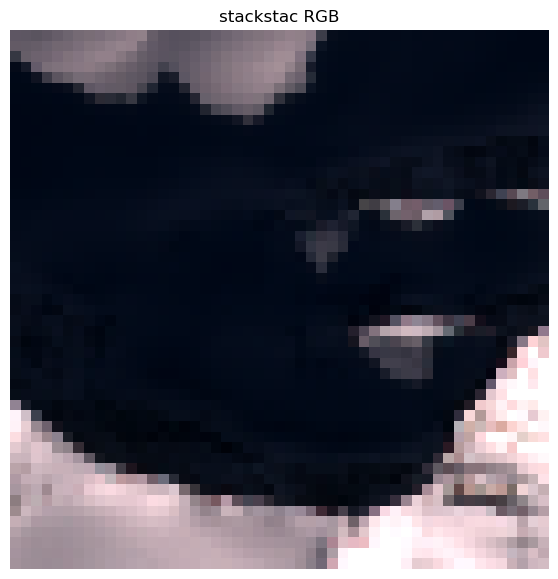

In [51]:
# Trigger a small read and display RGB. This is the point where remote JP2 access occurs.
stack_rgb = stack_cube.sel(band=["B04", "B03", "B02"])
stack_values = np.asarray(np.squeeze(stack_rgb))
low, high = np.nanpercentile(stack_values, [2, 98])
stack_display = np.clip((stack_values - low) / (high - low), 0, 1)
plt.figure(figsize=(7, 7))
plt.imshow(np.moveaxis(stack_display, 0, -1))
plt.title("stackstac RGB")
plt.axis("off")
plt.show()